# Insurance Cost Prediction: EDA and Hypothesis Testing

## Project Overview
Predicting health insurance premiums based on individual health profiles and demographics.

## Dataset
- **Source:** Capstone project dataset
- **Records:** 986
- **Features:** 10 input features + 1 target (PremiumPrice)
- **Missing values:** None

## Notebook Structure
1. Data Loading and First Look
2. Distribution Analysis
3. Feature-wise Analysis
4. Correlation Analysis
5. Outlier Detection
6. Feature Engineering (BMI)
7. Hypothesis Testing

**1. Setup and Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print("Libraries loaded successfully")

Libraries loaded successfully


**2. Data Loading**

In [2]:
# Load the dataset directly from GitHub

df = pd.read_csv('https://raw.githubusercontent.com/pallabiroyds/insurance-cost-prediction/refs/heads/main/data/insurance.csv')

print("Data loaded successfully")


Data loaded successfully


**3. Data Overview**

In [3]:
# Shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

# Column names
print("Columns:", df.columns.tolist())
print()

# Data types and non-null counts
print(df.info())
print()

# Missing values
print("Missing values per column:")
print(df.isnull().sum())
print()

# First 5 rows
df.head()

Rows: 986, Columns: 11

Columns: ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null   

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


**4. Descriptive Statistics**

Summary statistics for all features. Key things to look for:

*   Central tendency (mean versus median) to detect skewness
*   Minimum and maximum ranges to spot potential outliers
*   For binary columns (0/1), the mean represents the proportion with that condition

In [4]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


**5. Distribution Analysis**

**5.1 Target Variable: PremiumPrice**

*   Understanding the distribution of what we're predicting. Looking for skewness, modality, and spread.

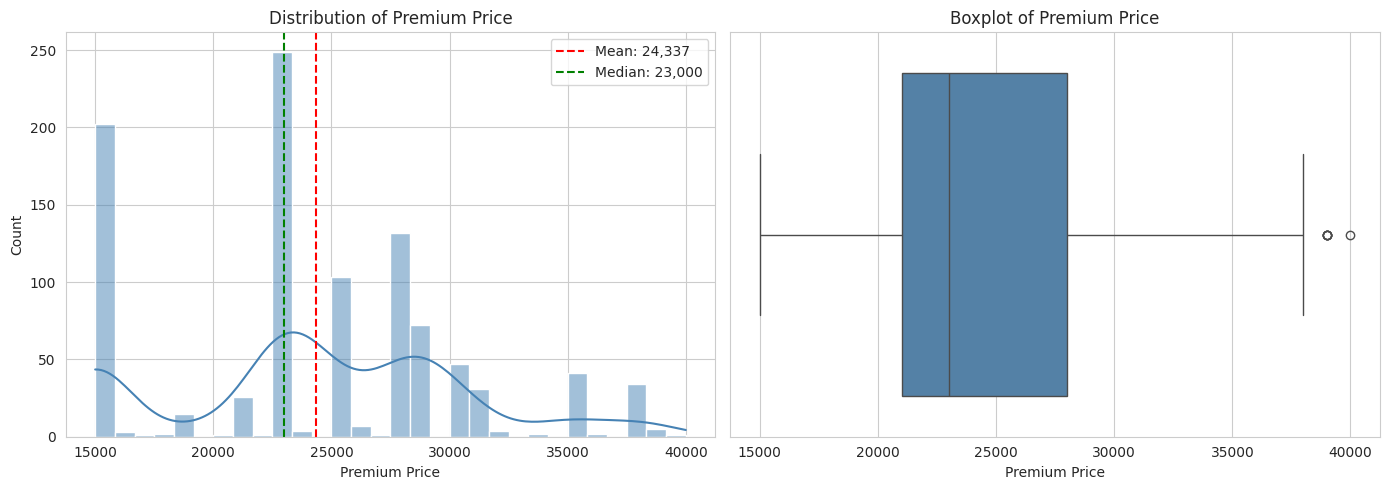

Mean:   24,337
Median: 23,000
Skew:   0.098


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['PremiumPrice'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Premium Price')
axes[0].set_xlabel('Premium Price')
axes[0].set_ylabel('Count')
axes[0].axvline(df['PremiumPrice'].mean(), color='red', linestyle='--', label=f"Mean: {df['PremiumPrice'].mean():,.0f}")
axes[0].axvline(df['PremiumPrice'].median(), color='green', linestyle='--', label=f"Median: {df['PremiumPrice'].median():,.0f}")
axes[0].legend()

# Boxplot
sns.boxplot(x=df['PremiumPrice'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Premium Price')
axes[1].set_xlabel('Premium Price')

plt.tight_layout()
plt.show()

# Print key stats
print(f"Mean:   {df['PremiumPrice'].mean():,.0f}")
print(f"Median: {df['PremiumPrice'].median():,.0f}")
print(f"Skew:   {df['PremiumPrice'].skew():.3f}")

**Observations:**
- Distribution is multimodal with three visible peaks around 15,000, 23,000, and 28,000-29,000
- This suggests three distinct premium tiers (low/medium/high risk groups)
- Large concentration at 15,000 (minimum premium) — possible base rate for low-risk individuals
- Nearly symmetric overall (skew = 0.098)
- Two potential outliers above 37,000 visible in the boxplot
- IQR: 21,000 - 28,000

**5.2 Age vs Premium Price**

*   Age is a continuous variable like our target. Scatter plot to check the relationship.

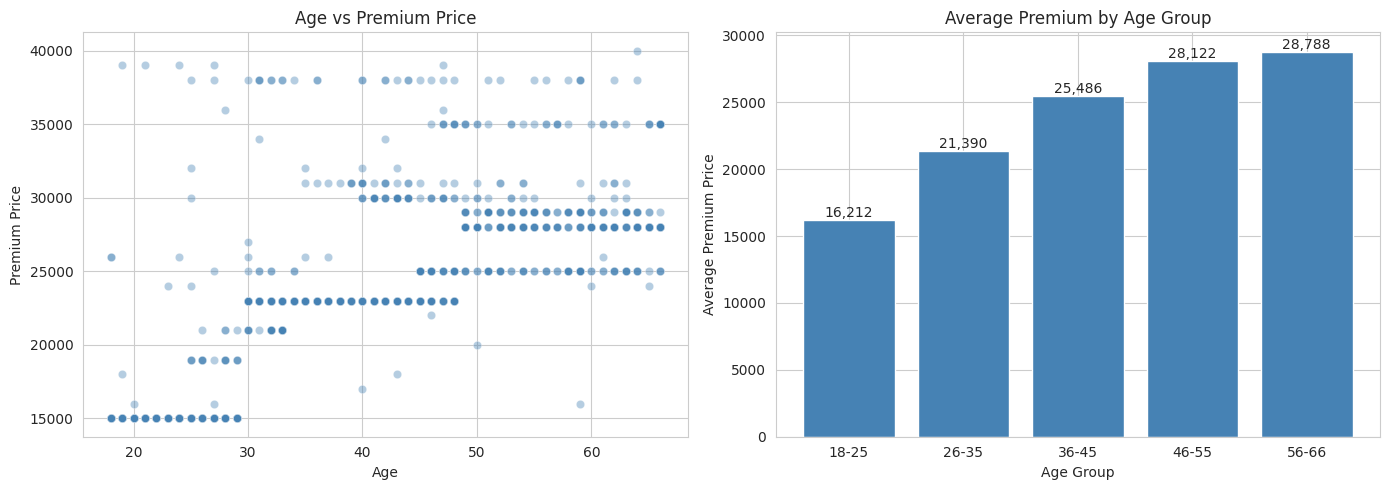

Pearson correlation (Age vs Premium): 0.698


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(df['Age'], df['PremiumPrice'], alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5)
axes[0].set_title('Age vs Premium Price')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Premium Price')

# Age binned into groups — average premium per group
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 66], labels=['18-25', '26-35', '36-45', '46-55', '56-66'])
age_premium = df.groupby('AgeGroup')['PremiumPrice'].mean()
axes[1].bar(age_premium.index, age_premium.values, color='steelblue', edgecolor='white')
axes[1].set_title('Average Premium by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Premium Price')

# Add value labels on bars
for i, v in enumerate(age_premium.values):
    axes[1].text(i, v + 200, f'{v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Correlation
print(f"Pearson correlation (Age vs Premium): {df['Age'].corr(df['PremiumPrice']):.3f}")

**Observations:**
- Strong positive correlation between Age and Premium (r = 0.698)
- Average premium nearly doubles from youngest (16,212) to oldest (28,788)
- However, at any given age, premiums vary widely (e.g., age 25: 15K to 38K)
- This vertical spread suggests other features (health conditions) contribute significantly
- The three age clusters (young/middle/senior) roughly map to the three premium tiers observed in the target distribution

**5.3 Binary Health Features vs Premium Price**

*   Comparing premium distributions for people with vs without each health condition.

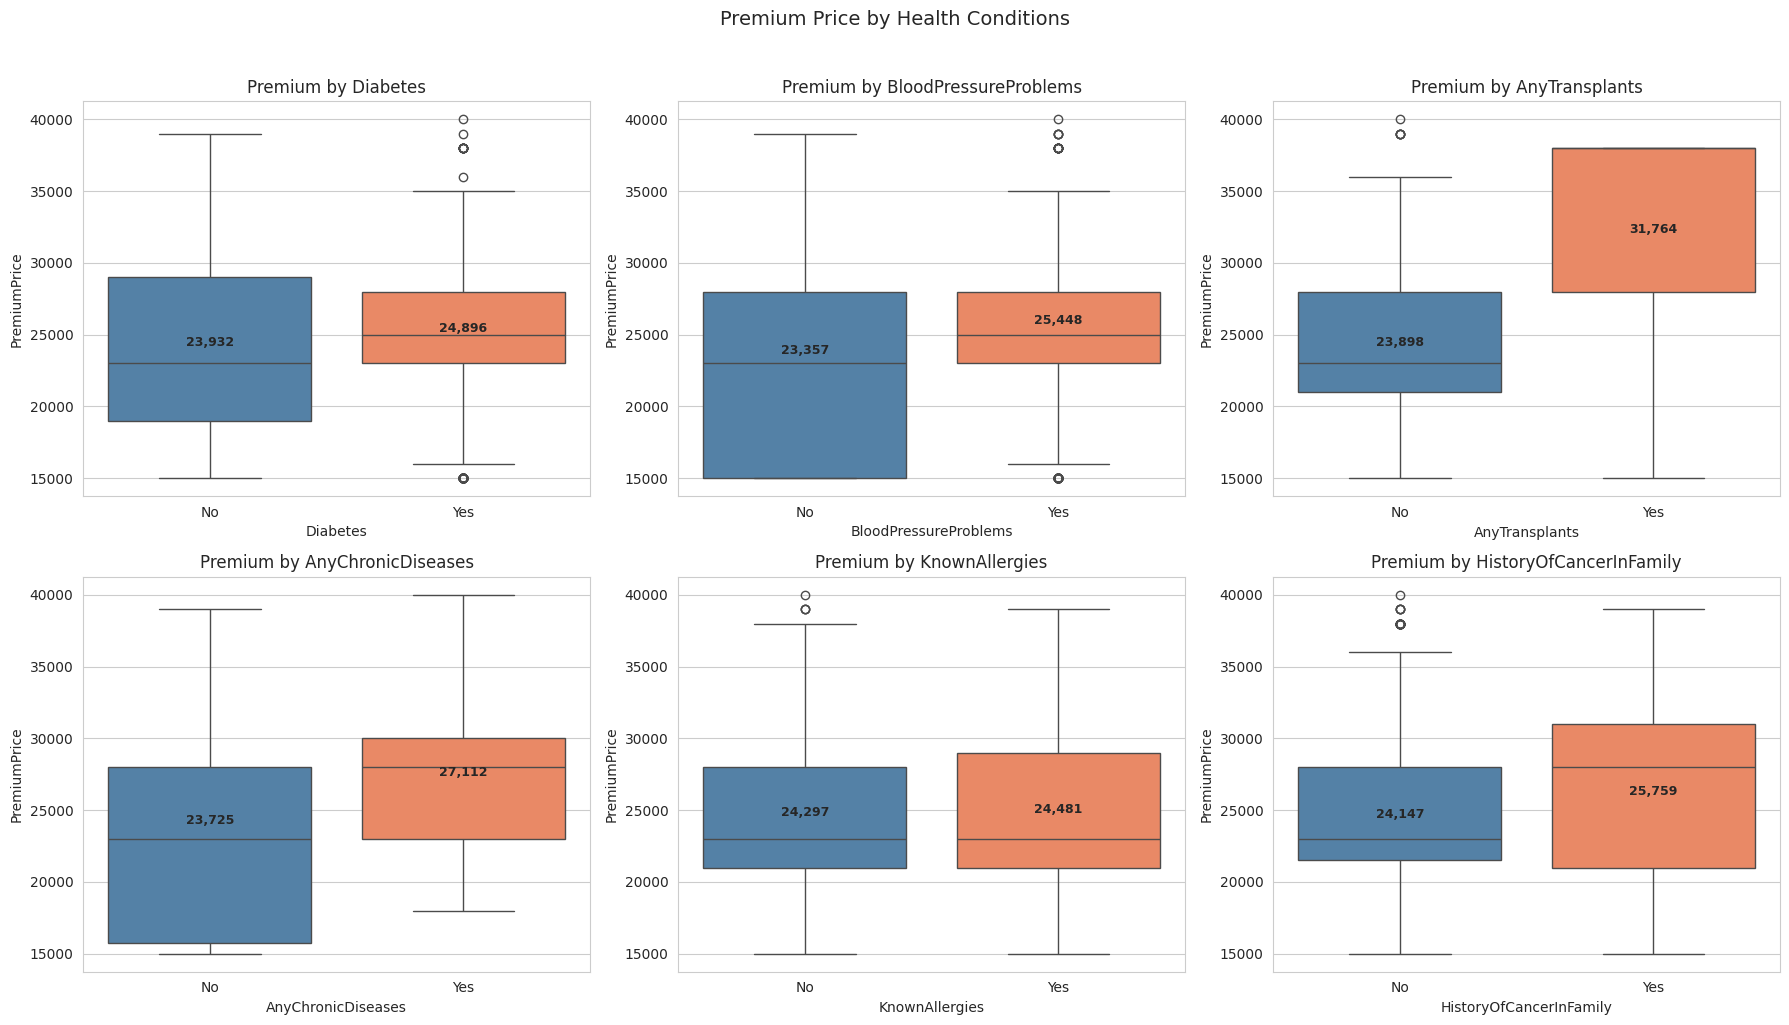

In [7]:
binary_cols = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants',
               'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.boxplot(x=col, y='PremiumPrice', data=df, ax=axes[i], palette=['steelblue', 'coral'])
    axes[i].set_title(f'Premium by {col}')
    axes[i].set_xticklabels(['No', 'Yes'])

    # Add mean values
    means = df.groupby(col)['PremiumPrice'].mean()
    for j, mean in enumerate(means):
        axes[i].text(j, mean + 300, f'{mean:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Premium Price by Health Conditions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- AnyTransplants shows the largest premium difference (+7,866), but it has the smallest sample (only ~6% of data)
- AnyChronicDiseases (+3,387) and BloodPressureProblems (+2,091) show meaningful differences
- Diabetes shows a surprisingly small gap (+964) despite being the most common condition (42%)
- KnownAllergies shows almost no premium difference (+184); likely not a useful predictor
- Hypothesis testing needed to confirm which differences are statistically significant vs. random chance

**5.4 Number of Major Surgeries vs Premium Price**

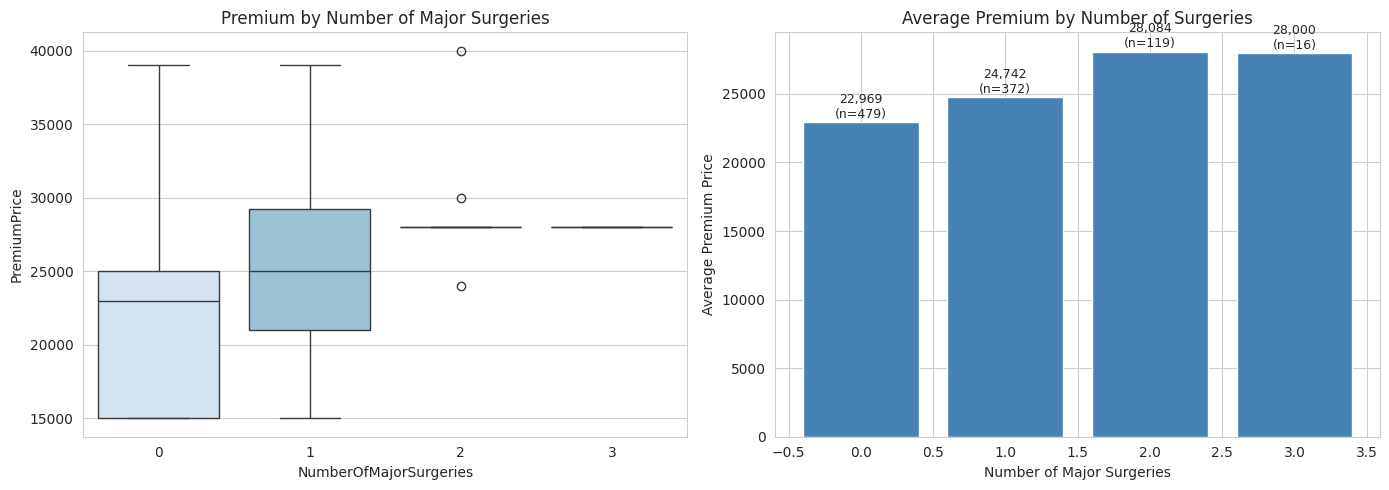

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='NumberOfMajorSurgeries', y='PremiumPrice', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Premium by Number of Major Surgeries')

# Mean premium per surgery count
surgery_premium = df.groupby('NumberOfMajorSurgeries')['PremiumPrice'].agg(['mean', 'count'])
bars = axes[1].bar(surgery_premium.index, surgery_premium['mean'], color='steelblue', edgecolor='white')
axes[1].set_title('Average Premium by Number of Surgeries')
axes[1].set_xlabel('Number of Major Surgeries')
axes[1].set_ylabel('Average Premium Price')

# Add mean and count labels
for i, (mean, count) in enumerate(zip(surgery_premium['mean'], surgery_premium['count'])):
    axes[1].text(i, mean + 300, f'{mean:,.0f}\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Observations:**
- Clear upward trend: more surgeries → higher premiums
- 0 surgeries (22,969) to 2 surgeries (28,084) shows consistent increase of ~5,000
- 3 surgeries group (28,000) has only n=16 — too small for reliable conclusions
- Nearly half the dataset (n=479) has zero surgeries
- ANOVA test needed to confirm if the differences across groups are statistically significant

**5.5 Correlation Heatmap**

*   Visualizing pairwise correlations between all numerical features to identify the strongest predictors of PremiumPrice.

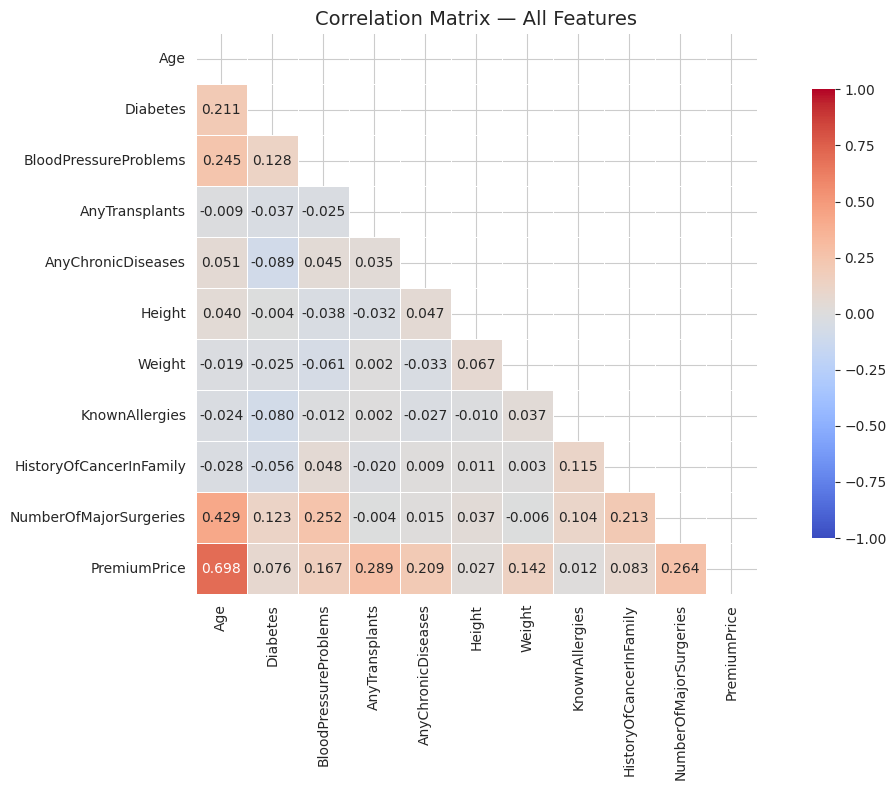

Correlations with PremiumPrice (sorted):
Age                        0.697540
AnyTransplants             0.289056
NumberOfMajorSurgeries     0.264250
AnyChronicDiseases         0.208610
BloodPressureProblems      0.167097
Weight                     0.141507
HistoryOfCancerInFamily    0.083139
Diabetes                   0.076209
Height                     0.026910
KnownAllergies             0.012103


In [9]:
plt.figure(figsize=(12, 8))

corr_matrix = df.drop(columns=['AgeGroup']).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix — All Features', fontsize=14)
plt.tight_layout()
plt.show()

# Extract correlations with target
print("Correlations with PremiumPrice (sorted):")
print(corr_matrix['PremiumPrice'].drop('PremiumPrice').sort_values(ascending=False).to_string())

**Observations:**
- Age is the dominant predictor (r = 0.698) — more than 2x stronger than any other feature
- AnyTransplants (0.289), NumberOfMajorSurgeries (0.264), and AnyChronicDiseases (0.209) form a second tier
- Diabetes (0.076) and KnownAllergies (0.012) have negligible correlation with premium — likely weak predictors
- Notable multicollinearity: Age and NumberOfMajorSurgeries (0.429) — older people tend to have more surgeries
- No strong negative correlations exist in this dataset

**5.6 Outlier Detection**


*   Using IQR method to identify outliers in continuous variables.

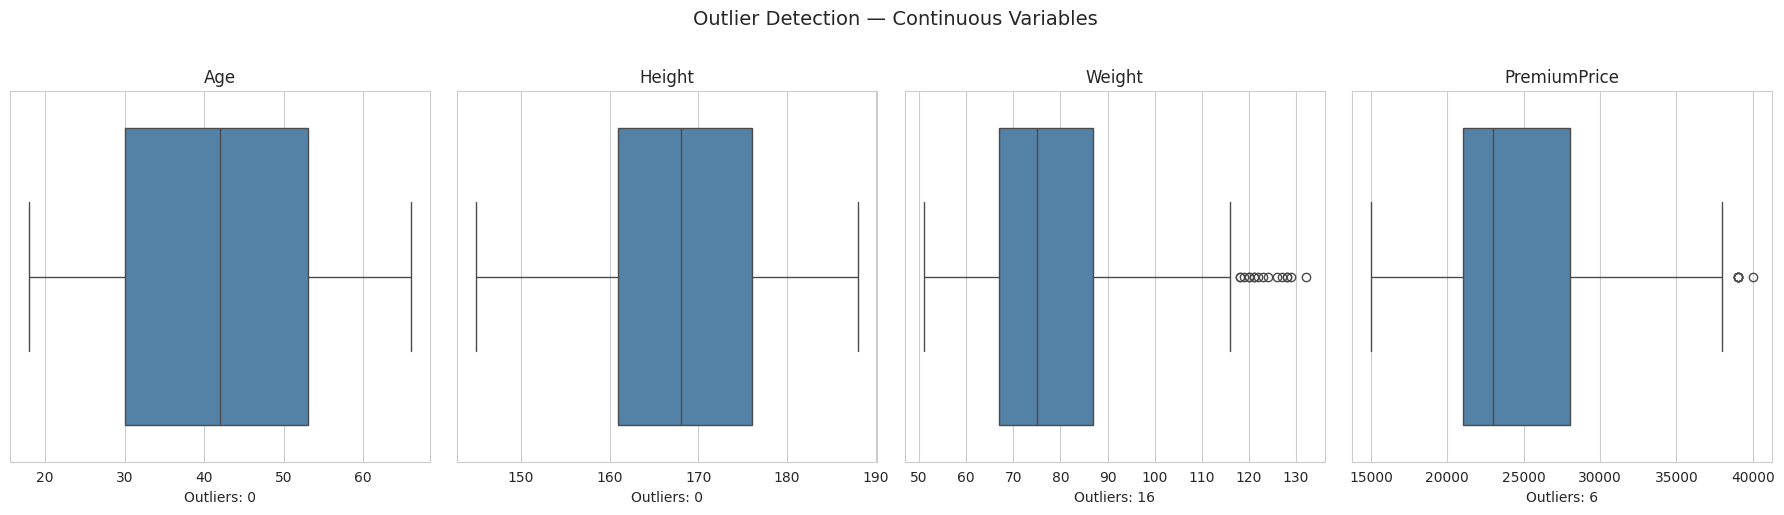

OUTLIER SUMMARY (IQR Method)
Age: 0 outliers (bounds: -4 - 88)
Height: 0 outliers (bounds: 138 - 198)
Weight: 16 outliers (bounds: 37 - 117)
PremiumPrice: 6 outliers (bounds: 10500 - 38500)


In [10]:
continuous_cols = ['Age', 'Height', 'Weight', 'PremiumPrice']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(continuous_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}')

    # Calculate IQR outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    axes[i].set_xlabel(f'Outliers: {len(outliers)}')

plt.suptitle('Outlier Detection — Continuous Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print outlier summary
print("OUTLIER SUMMARY (IQR Method)")
print("=" * 50)
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.0f} - {upper:.0f})")

**Observations:**
- Age and Height: no outliers
- Weight: 16 outliers on the high end (heavy individuals)
- PremiumPrice: 6 outliers on the high end (high-risk individuals)
- Decision: retain all outliers; these appear to be legitimate data points, not errors
- Tree-based models (Random Forest, Gradient Boosting) are robust to outliers, so this won't impact our primary modeling approach

**5.7 Feature Engineering — BMI**

*   Creating Body Mass Index from Height and Weight. BMI = weight(kg) / height(m)²




BMI Statistics:
  Mean:   27.5
  Min:    15.2
  Max:    50.0



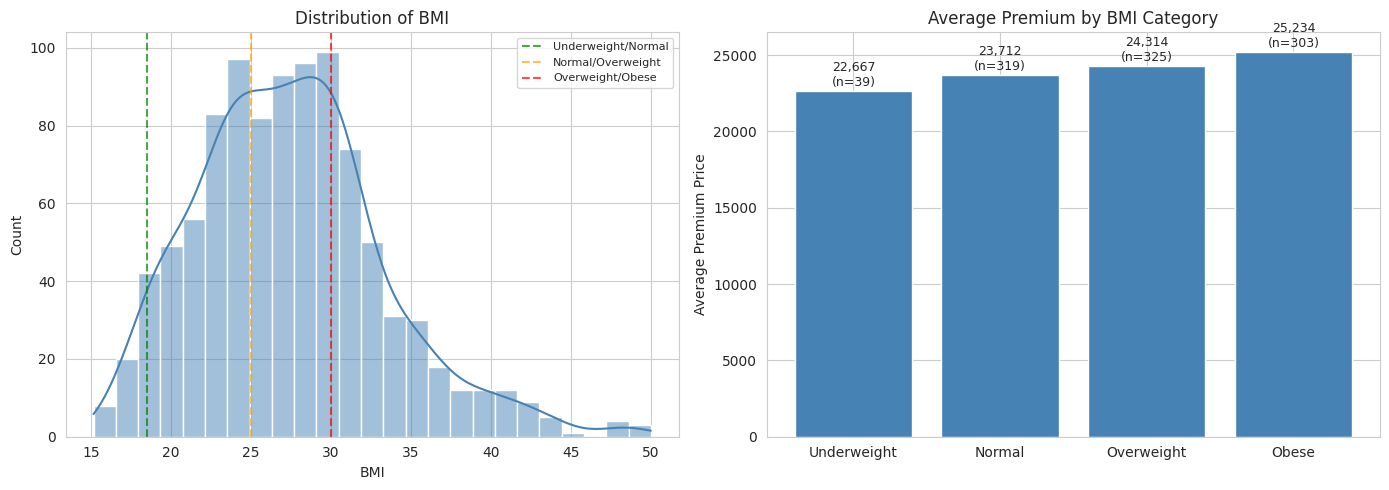


Correlation of BMI with PremiumPrice: 0.104
Compare with Weight alone:            0.142
Compare with Height alone:            0.027


In [11]:
# Create BMI feature
df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2

print(f"BMI Statistics:")
print(f"  Mean:   {df['BMI'].mean():.1f}")
print(f"  Min:    {df['BMI'].min():.1f}")
print(f"  Max:    {df['BMI'].max():.1f}")
print()

# BMI categories (WHO standard)
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BMI distribution
sns.histplot(df['BMI'], bins=25, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of BMI')
axes[0].set_xlabel('BMI')
axes[0].axvline(18.5, color='green', linestyle='--', alpha=0.7, label='Underweight/Normal')
axes[0].axvline(25, color='orange', linestyle='--', alpha=0.7, label='Normal/Overweight')
axes[0].axvline(30, color='red', linestyle='--', alpha=0.7, label='Overweight/Obese')
axes[0].legend(fontsize=8)

# Average premium by BMI category
order = ['Underweight', 'Normal', 'Overweight', 'Obese']
bmi_premium = df.groupby('BMI_Category')['PremiumPrice'].agg(['mean', 'count']).reindex(order)
axes[1].bar(bmi_premium.index, bmi_premium['mean'], color='steelblue', edgecolor='white')
axes[1].set_title('Average Premium by BMI Category')
axes[1].set_ylabel('Average Premium Price')

for i, (mean, count) in enumerate(zip(bmi_premium['mean'], bmi_premium['count'])):
    axes[1].text(i, mean + 300, f'{mean:,.0f}\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Correlation of BMI with Premium
print(f"\nCorrelation of BMI with PremiumPrice: {df['BMI'].corr(df['PremiumPrice']):.3f}")
print(f"Compare with Weight alone:            {df['Weight'].corr(df['PremiumPrice']):.3f}")
print(f"Compare with Height alone:            {df['Height'].corr(df['PremiumPrice']):.3f}")

**Observations:**
- BMI distribution is right-skewed, most individuals fall in Normal to Overweight range
- BMI correlation with Premium (0.104) is actually weaker than Weight alone (0.142)
- Premium differences across BMI categories are modest (~2,500 from Underweight to Obese)
- BMI will be retained as a feature (project requirement) but is not expected to be a strong predictor
- Lesson: engineered features don't always outperform raw features; let the data decide